## Reading Data Set

In [1]:
import pandas as pd

data=pd.read_csv("telecom_customer_churn.csv")
data1=pd.read_csv("telecom_customer_churn.csv")

## DATA PREPROCESSING

In [2]:
data=data[data["Customer Status"] != "Joined"]

In [3]:
data.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
Married,0
Number of Dependents,0
City,0
Zip Code,0
Latitude,0
Longitude,0
Number of Referrals,0


### Replacing NULL Values

In [4]:
import numpy as np
mode=data["Internet Type"].mode()[0]
data["Internet Type"]=data["Internet Type"].fillna(mode)


mean=np.mean(data["Avg Monthly GB Download"])
data["Avg Monthly GB Download"]=data["Avg Monthly GB Download"].fillna(mean)


mode=data["Online Security"].mode()[0]
data["Online Security"]=data["Online Security"].fillna(mode)


mode=data["Online Backup"].mode()[0]
data["Online Backup"]=data["Online Backup"].fillna(mode)


mode=data["Device Protection Plan"].mode()[0]
data["Device Protection Plan"]=data["Device Protection Plan"].fillna(mode)


mode=data["Premium Tech Support"].mode()[0]
data["Premium Tech Support"]=data["Premium Tech Support"].fillna(mode)


mode=data["Streaming TV"].mode()[0]
data["Streaming TV"]=data["Streaming TV"].fillna(mode)


mode=data["Streaming Movies"].mode()[0]
data["Streaming Movies"]=data["Streaming Movies"].fillna(mode)


mode=data["Streaming Music"].mode()[0]
data["Streaming Music"]=data["Streaming Music"].fillna(mode)


mode=data["Unlimited Data"].mode()[0]
data["Unlimited Data"]=data["Unlimited Data"].fillna(mode)


mean=np.mean(data["Avg Monthly Long Distance Charges"])
data["Avg Monthly Long Distance Charges"]=data["Avg Monthly Long Distance Charges"].fillna(mean)


mode=data["Multiple Lines"].mode()[0]
data["Multiple Lines"]=data["Multiple Lines"].fillna(mode)

In [5]:
data.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
Married,0
Number of Dependents,0
City,0
Zip Code,0
Latitude,0
Longitude,0
Number of Referrals,0


### Dropping off columns that dont impact our model prediction

In [6]:
data=data.drop(columns=["Customer ID","City","Zip Code","Latitude","Longitude","Offer","Churn Category","Churn Reason"])

### Balancing Dataset

In [7]:
from imblearn.over_sampling import RandomOverSampler
ros=RandomOverSampler(random_state=16)
x=data.drop(columns="Customer Status")
y=data["Customer Status"]
x_resample,y_resample=ros.fit_resample(x,y)

### Removing columns that are less corelated with the target column

In [8]:
x_resample=x_resample.drop(columns=["Avg Monthly GB Download","Online Security","Unlimited Data","Total Refunds","Gender","Avg Monthly Long Distance Charges","Total Extra Data Charges","Multiple Lines","Phone Service","Streaming Music","Internet Type"])

### Label Encoding

In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
cols=["Married","Internet Service","Online Backup","Device Protection Plan","Premium Tech Support","Streaming TV","Streaming Movies","Contract","Paperless Billing","Payment Method"]
y_resample=pd.DataFrame(y_resample,columns=["Customer Status"])
le1=LabelEncoder()
label_encoder={}
for col in cols:
    le=LabelEncoder()
    x_resample[col]=le.fit_transform(x_resample[col])
    label_encoder[col]=le
y_resample=le1.fit_transform(y_resample["Customer Status"])
print(x_resample.columns.to_list())
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_scaled_data=sc.fit_transform(x_resample)
x_scaled_data=pd.DataFrame(x_scaled_data,columns=x_resample.columns)

data2=x_scaled_data
data2["Customer Status"]=y_resample


['Age', 'Married', 'Number of Dependents', 'Number of Referrals', 'Tenure in Months', 'Internet Service', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Long Distance Charges', 'Total Revenue']


In [11]:
target_column="Customer Status"
corr_with_target=data2.corr()[target_column].drop(target_column)
corr_sorted=corr_with_target.sort_values(ascending=False)
corr_sorted

,Customer Status
Contract,0.566604
Tenure in Months,0.483960
Number of Referrals,0.388627
Total Revenue,0.317680
Total Long Distance Charges,0.313972
Total Charges,0.287977
Number of Dependents,0.277116
Payment Method,0.234547
Premium Tech Support,0.206364
Married,0.205140


In [12]:
corelation_matrix=data2.corr()
corelation_matrix.to_csv("corelation_matrix.csv")

In [13]:
import pickle

# after fitting all your encoders, scaler, and model
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(sc, f)


In [14]:
x=data2.drop(columns=["Customer Status"])
y=data2["Customer Status"]

## SPLITTING DATASET

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=16)

## ALGORITHM SELECTION

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [18]:
from sklearn.model_selection import KFold
kf=KFold(n_splits=5,shuffle=True,random_state=16)

In [19]:
lr=LogisticRegression()
knn=KNeighborsClassifier()
dtc=DecisionTreeClassifier()
rf=RandomForestClassifier()
nb=GaussianNB()

In [20]:
lr.fit(x_train,y_train)
knn.fit(x_train,y_train)
dtc.fit(x_train,y_train)
rf.fit(x_train,y_train)
nb.fit(x_train,y_train)

GaussianNB()

## METRICS

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score

model_metrics_results=[]

def evaluate_model(model_name, model, x_train, x_test, y_train, y_test):
    y_pred_test=model.predict(x_test)
    y_pred_train=model.predict(x_train)
    y_score=model.predict_proba(x_test)[:,1]

    result={
        "Model": model_name,
        "Accuracy": accuracy_score(y_test,y_pred_test),
        "AUC Score": roc_auc_score(y_test,y_score),
        "Precision": precision_score(y_test,y_pred_test),
        "Recall": recall_score(y_test,y_pred_test),
        "F1 Score": f1_score(y_test,y_pred_test),
        "MCC Score": matthews_corrcoef(y_test,y_pred_test),
        "Train Accuracy": accuracy_score(y_train,y_pred_train)
    }
    model_metrics_results.append(result)

    print(model_name)
    print(classification_report(y_test,y_pred_test))
    print("Accuracy : ", result["Accuracy"])
    print("AUC Score : ", result["AUC Score"])
    print("Precision : ", result["Precision"])
    print("Recall : ", result["Recall"])
    print("F1 Score : ", result["F1 Score"])
    print("MCC Score : ", result["MCC Score"])
    print("Train Accuracy : ", result["Train Accuracy"])
    print()

In [22]:
evaluate_model("Logistic Regression", lr, x_train, x_test, y_train, y_test)

Logistic Regression
              precision    recall  f1-score   support

           0       0.81      0.88      0.85       934
           1       0.87      0.80      0.83       954

    accuracy                           0.84      1888
   macro avg       0.84      0.84      0.84      1888
weighted avg       0.84      0.84      0.84      1888

Accuracy :  0.840042372881356
AUC Score :  0.9171638407426861
Precision :  0.8738532110091743
Recall :  0.7987421383647799
F1 Score :  0.8346111719605696
MCC Score :  0.6829201810559689
Train Accuracy :  0.8250794491525424



In [23]:
from sklearn.feature_selection import RFE
model=LogisticRegression(max_iter=1000)
rfe=RFE(model,n_features_to_select=10)
fit=rfe.fit(x,y)
selected_features=x.columns[fit.support_]
print("selected features")
list(selected_features)
feature_ranking=pd.DataFrame({
    "Feature ":x.columns,
    "Rank ": fit.ranking_
})
print(feature_ranking.sort_values("Rank "))

selected features
                       Feature   Rank 
1                       Married      1
2          Number of Dependents      1
3           Number of Referrals      1
4              Tenure in Months      1
5              Internet Service      1
15                Total Charges      1
13               Payment Method      1
11                     Contract      1
17                Total Revenue      1
16  Total Long Distance Charges      1
8          Premium Tech Support      2
0                           Age      3
12            Paperless Billing      4
9                  Streaming TV      5
14               Monthly Charge      6
6                 Online Backup      7
7        Device Protection Plan      8
10             Streaming Movies      9


In [24]:
evaluate_model("K-Nearest Neighbor Classifier", knn, x_train, x_test, y_train, y_test)

K-Nearest Neighbor Classifier
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       934
           1       0.88      0.76      0.82       954

    accuracy                           0.83      1888
   macro avg       0.83      0.83      0.83      1888
weighted avg       0.83      0.83      0.83      1888

Accuracy :  0.8268008474576272
AUC Score :  0.9087842690979938
Precision :  0.8781664656212304
Recall :  0.7631027253668763
F1 Score :  0.8166012338754908
MCC Score :  0.6598434714318446
Train Accuracy :  0.8752648305084746



In [25]:
evaluate_model("Decision Tree Classifier", dtc, x_train, x_test, y_train, y_test)

Decision Tree Classifier
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       934
           1       0.96      0.88      0.92       954

    accuracy                           0.92      1888
   macro avg       0.92      0.92      0.92      1888
weighted avg       0.92      0.92      0.92      1888

Accuracy :  0.9189618644067796
AUC Score :  0.9193736280015623
Precision :  0.9556313993174061
Recall :  0.8805031446540881
F1 Score :  0.9165302782324058
MCC Score :  0.8406954891750178
Train Accuracy :  1.0



In [26]:
evaluate_model("Random Forest (Ensemble)", rf, x_train, x_test, y_train, y_test)

Random Forest (Ensemble)
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       934
           1       0.95      0.92      0.93       954

    accuracy                           0.93      1888
   macro avg       0.94      0.94      0.93      1888
weighted avg       0.94      0.93      0.93      1888

Accuracy :  0.9348516949152542
AUC Score :  0.9864534092898604
Precision :  0.9540983606557377
Recall :  0.9150943396226415
F1 Score :  0.9341894060995185
MCC Score :  0.8704884909994578
Train Accuracy :  1.0



In [27]:
importances=rf.feature_importances_
for i,imp in enumerate(importances):
    print(f"Feature {i} : {imp}")

Feature 0 : 0.07103258586368359
Feature 1 : 0.011585592501539874
Feature 2 : 0.03961710776402509
Feature 3 : 0.09398080751184963
Feature 4 : 0.1307732297431745
Feature 5 : 0.02281830275983019
Feature 6 : 0.010252085124876052
Feature 7 : 0.009492129821360487
Feature 8 : 0.015104064182997519
Feature 9 : 0.008729845876432479
Feature 10 : 0.009523147354597559
Feature 11 : 0.16648229302560721
Feature 12 : 0.014384074293568739
Feature 13 : 0.02171460235384916
Feature 14 : 0.10519480571787548
Feature 15 : 0.09695383251053875
Feature 16 : 0.07586486502194188
Feature 17 : 0.09649662857225184


In [28]:
evaluate_model("Naive Bayes Classifier", nb, x_train, x_test, y_train, y_test)

Naive Bayes Classifier
              precision    recall  f1-score   support

           0       0.78      0.81      0.80       934
           1       0.81      0.78      0.80       954

    accuracy                           0.80      1888
   macro avg       0.80      0.80      0.80      1888
weighted avg       0.80      0.80      0.80      1888

Accuracy :  0.7976694915254238
AUC Score :  0.880511561822418
Precision :  0.8115468409586056
Recall :  0.7809224318658281
F1 Score :  0.7959401709401709
MCC Score :  0.5958902268024503
Train Accuracy :  0.7880031779661016



In [29]:
comparison_table=pd.DataFrame(model_metrics_results)
comparison_table[["Model","Accuracy","AUC Score","Precision","Recall","F1 Score","MCC Score","Train Accuracy"]].round(4)

,Model,Accuracy,AUC Score,Precision,Recall,F1 Score,MCC Score,Train Accuracy
0,Logistic Regression,0.8400,0.9172,0.8739,0.7987,0.8346,0.6829,0.8251
1,K-Nearest Neighbor Classifier,0.8268,0.9088,0.8782,0.7631,0.8166,0.6598,0.8753
2,Decision Tree Classifier,0.9190,0.9194,0.9556,0.8805,0.9165,0.8407,1.0000
3,Random Forest (Ensemble),0.9349,0.9865,0.9541,0.9151,0.9342,0.8705,1.0000
4,Naive Bayes Classifier,0.7977,0.8805,0.8115,0.7809,0.7959,0.5959,0.7880


In [30]:
comparison_table.sort_values(by=["F1 Score","AUC Score","Accuracy"], ascending=False).reset_index(drop=True).round(4)

,Model,Accuracy,AUC Score,Precision,Recall,F1 Score,MCC Score,Train Accuracy
0,Random Forest (Ensemble),0.9349,0.9865,0.9541,0.9151,0.9342,0.8705,1.0000
1,Decision Tree Classifier,0.9190,0.9194,0.9556,0.8805,0.9165,0.8407,1.0000
2,Logistic Regression,0.8400,0.9172,0.8739,0.7987,0.8346,0.6829,0.8251
3,K-Nearest Neighbor Classifier,0.8268,0.9088,0.8782,0.7631,0.8166,0.6598,0.8753
4,Naive Bayes Classifier,0.7977,0.8805,0.8115,0.7809,0.7959,0.5959,0.7880


In [31]:
from sklearn.model_selection import cross_val_score
score=cross_val_score(rf,x,y,cv=kf)
print(score)

[0.93644068 0.93908898 0.93114407 0.93220339 0.93485169]


In [32]:
from pathlib import Path
import pickle

model_dir = Path("model")
model_dir.mkdir(exist_ok=True)

trained_models = {
    "logistic_regression.pkl": lr,
    "decision_tree_classifier.pkl": dtc,
    "k_nearest_neighbor_classifier.pkl": knn,
    "naive_bayes_classifier.pkl": nb,
    "random_forest_ensemble.pkl": rf,
}

for file_name, model_obj in trained_models.items():
    with open(model_dir / file_name, "wb") as f:
        pickle.dump(model_obj, f)

print("Saved model files:")
for file_name in trained_models:
    print(model_dir / file_name)

Saved model files:
model/logistic_regression.pkl
model/decision_tree_classifier.pkl
model/k_nearest_neighbor_classifier.pkl
model/naive_bayes_classifier.pkl
model/random_forest_ensemble.pkl


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

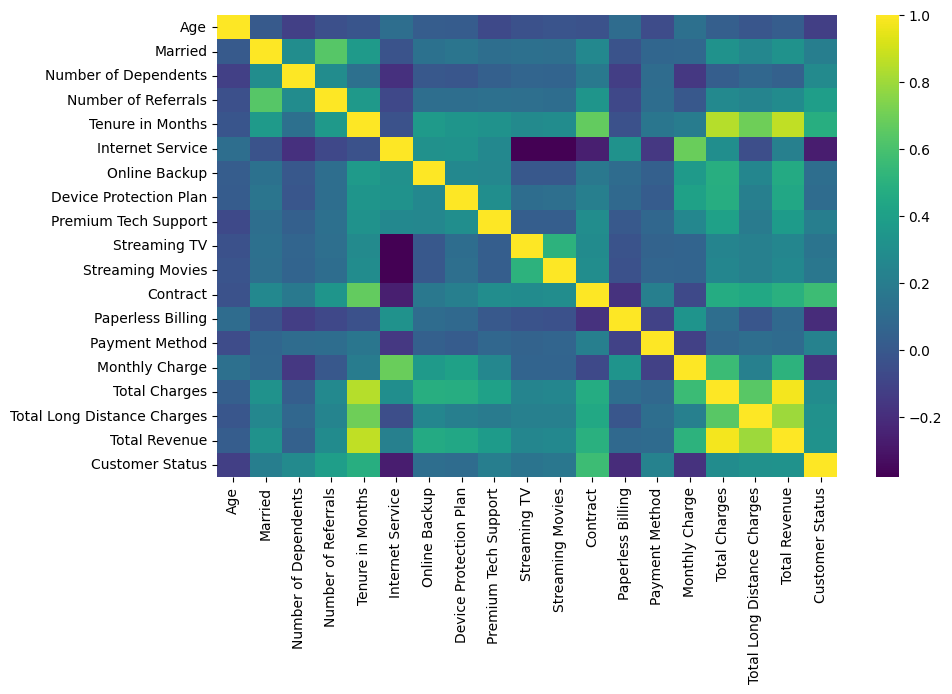

In [34]:
plt.figure(figsize=(10,6))
sns.heatmap(corelation_matrix,annot=False,cmap="viridis",fmt=".2f")